In [12]:
import math

import torch
from llmfromscratch.llm_arch import GPTModel

In [13]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,    #1
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,       #2
    "qkv_bias": False
}

In [14]:
torch.manual_seed(123)

In [15]:
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

## 5.1 Evaluating Generative Text Models

In [16]:
import tiktoken
from llmfromscratch.llm_gen import generate_text_simplified

def text_to_token_ids(text, tokenizer):
    token_ids = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(token_ids).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flatten_text = token_ids.squeeze(0).tolist()
    decoded_text = tokenizer.decode(flatten_text)
    return decoded_text

In [17]:
start_text = "Every effort moves you closer to"
tokenizer = tiktoken.get_encoding("gpt2")
encoded_tensor = text_to_token_ids(start_text, tokenizer)
encoded_tensor

tensor([[6109, 3626, 6100,  345, 5699,  284]])

In [18]:
decoded_text = token_ids_to_text(encoded_tensor, tokenizer)
decoded_text

'Every effort moves you closer to'

In [19]:
generated_token_ids = generate_text_simplified(
                                model = model,
                                idx = encoded_tensor,
                                max_new_tokens = 100,
                                context_size = GPT_CONFIG_124M["context_length"]
                            )

In [20]:
#with CUDA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
encoded_tensor = encoded_tensor.to(device)

In [21]:
#with CUDA
generated_token_ids = generate_text_simplified(
                                model = model,
                                idx = encoded_tensor,
                                max_new_tokens = 100,
                                context_size = GPT_CONFIG_124M["context_length"]
                            )

In [22]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

In [23]:
inputs = inputs.to(device)

with torch.no_grad():
    logits = model(inputs)
token_probas = torch.softmax(logits, dim=-1)


In [24]:
token_probas.shape

torch.Size([2, 3, 50257])

In [25]:
pred_token_ids = torch.argmax(token_probas, dim = -1, keepdim = True)
pred_token_ids

tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]], device='cuda:0')

In [26]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(pred_token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


In [27]:
pred_token_ids[0].flatten().squeeze(0)

tensor([16657,   339, 42826], device='cuda:0')

In [29]:
token_probas.shape

torch.Size([2, 3, 50257])

In [30]:
text_idx = 0
target_probas_1 = token_probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = token_probas[text_idx, [0,1,2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05], device='cuda:0')
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06], device='cuda:0')


In [31]:
target_probas = torch.cat((target_probas_1, target_probas_2))

In [32]:
target_probas

tensor([7.4540e-05, 3.1061e-05, 1.1563e-05, 1.0337e-05, 5.6776e-05, 4.7559e-06],
       device='cuda:0')

In [33]:
log_probas = torch.log(target_probas)
log_probas

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561],
       device='cuda:0')

In [34]:
avg_log_probas = torch.mean(log_probas, dim = -1)
avg_log_probas

tensor(-10.7940, device='cuda:0')

In [35]:
loss = (-1) * avg_log_probas

In [36]:
print("Logits shape:", token_probas.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [37]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [38]:
loss_ce = torch.nn.functional.cross_entropy(logits_flat.to(device), targets_flat.to(device))
loss_ce

tensor(10.7940, device='cuda:0')

## 5.3 Calculating the train and evaluation set losses.

In [39]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [40]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [41]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [42]:
from llmfromscratch.llm_gen import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [43]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [44]:
def calculate_batch_loss(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    out_batch = model(input_batch)
    y_pred = out_batch.flatten(0,1)
    y = target_batch.flatten(0)
    loss = torch.nn.functional.cross_entropy(y_pred, y)

    return loss

def calculate_loss_loader(data_loader, model, device, num_batches = None):
    batch_num = 0
    loss = 0

    if num_batches is None:
       num_batches = len(data_loader)
    elif num_batches <= 0:
        return float("nan")

    print("A1")
    for x, y in data_loader:
        if batch_num < num_batches:
            batch_num += 1
            batch_loss = calculate_batch_loss(x, y, model, device)
            loss += batch_loss.item()
            print(f"Batch {batch_num} loss: {batch_loss.item()}")
        else:
            break

    loss /= batch_num

    return loss

In [45]:

batch = next(iter(val_loader))

In [46]:
with torch.no_grad():
    loader_loss = calculate_loss_loader(train_loader, model, device, 100)
loader_loss

A1
Batch 1 loss: 10.98016357421875
Batch 2 loss: 10.991239547729492
Batch 3 loss: 11.002304077148438
Batch 4 loss: 10.960235595703125
Batch 5 loss: 11.01591682434082
Batch 6 loss: 10.96568489074707
Batch 7 loss: 10.99540901184082
Batch 8 loss: 11.005659103393555
Batch 9 loss: 10.971637725830078


10.987583372328016

In [47]:
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)   #1
with torch.no_grad():                                        #2
    train_loss = calculate_loss_loader(train_loader, model, device)    #3
    val_loss = calculate_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

A1
Batch 1 loss: 11.014039039611816
Batch 2 loss: 11.013160705566406
Batch 3 loss: 10.993927001953125
Batch 4 loss: 10.968860626220703
Batch 5 loss: 10.998101234436035
Batch 6 loss: 10.96236801147461
Batch 7 loss: 10.938627243041992
Batch 8 loss: 10.99979019165039
Batch 9 loss: 10.999375343322754
A1
Batch 1 loss: 10.98110580444336
Training loss: 10.987583266364204
Validation loss: 10.98110580444336


In [48]:
logits.shape

torch.Size([2, 3, 50257])

In [49]:
logits[:3,:4,:5]

tensor([[[ 0.1113, -0.1057, -0.3666,  0.0229, -0.6258],
         [-0.6109, -0.5167, -0.7613,  0.3486,  0.2534],
         [ 0.5707, -0.6459, -0.0701, -0.4314, -0.1892]],

        [[-0.2968,  0.1949, -0.1649, -0.9598, -0.3897],
         [-0.8375,  0.0612, -0.4641,  0.0688,  0.0849],
         [ 0.5614,  0.6919,  0.8915, -0.6628, -1.3406]]], device='cuda:0')

## 5.4 Training LLM

In [50]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  #1
    with torch.no_grad():                              #2
        train_loss = calculate_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calculate_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [51]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simplified(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))      #1
    model.train()

In [52]:
def train(model, train_lodaer, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []    #1
    tokens_seen, global_step = 0, -1

    for epoch_num in range(num_epochs):
        train_loss = 0
        val_loss = 0
        model.train()

        for batch_num, (input_batch, target_batch) in enumerate(train_loader):
            optimizer.zero_grad()
            ingered_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            batch_loss = calculate_batch_loss(input_batch, target_batch, model, device)
            #train_loss += batch_loss.item()
            batch_loss.backward()
            optimizer.step()

            global_step += 1
            tokens_seen += input_batch.shape[1]

            #train_loss /= (batch_num + 1)
            #print(f"Epoch {epoch_num} train loss: {train_loss}")

            if global_step % eval_freq == 0:    #6
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch_num+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

                #Printing sample text message after each batch
                #encoded_context = text_to_token_ids(start_context, tokenizer)
                #generate_text_simplified(model, encoded_context, 100, GPT_CONFIG_124M["context_length"])
                generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen


## 5.4.1 Enhancing training loop.

In [53]:
num_of_epoch = 15
min_lr = 1e-4
peak_lr = 0.01

In [54]:
total_batch_steps = len(train_loader) * num_of_epoch
warmup_steps =int(0.2 * total_batch_steps)
warmup_steps

27

In [55]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay = 0.1)


In [56]:
import math

def train_model_enhanced(model, train_lodaer, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer,
          initial_lr = 3e-5, min_lr = 1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []    #1
    tokens_seen, global_step = 0, -1
    total_batch_steps = len(train_loader) * num_epochs
    warmup_steps = int(0.2 * total_batch_steps)
    peak_lr = optimizer.param_groups[0]['lr']
    lr_increment = (peak_lr - initial_lr) / warmup_steps
    lr = 0

    for epoch_num in range(num_epochs):
        train_loss = 0
        val_loss = 0
        model.train()

        for batch_num, (input_batch, target_batch) in enumerate(train_loader):
            optimizer.zero_grad()
            batch_loss = calculate_batch_loss(input_batch, target_batch, model, device)
            #train_loss += batch_loss.item()

            if (global_step < warmup_steps):
            #Learning rate warm-up
                lr = initial_lr + global_step * lr_increment
            else:
            #Cosine lr decay
                progress = (global_step - warmup_steps) / (total_batch_steps - warmup_steps)
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            track_lrs.append(lr)
            batch_loss.backward()

            #Gradient Clipping
            if (global_step > warmup_steps):
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            global_step += 1
            tokens_seen += input_batch.shape[1]

            #train_loss /= (batch_num + 1)
            #print(f"Epoch {epoch_num} train loss: {train_loss}")

            if global_step % eval_freq == 0:    #6
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch_num+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

                #Printing sample text message after each batch
                #encoded_context = text_to_token_ids(start_context, tokenizer)
                #generate_text_simplified(model, encoded_context, 100, GPT_CONFIG_124M["context_length"])
                generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens_seen, track_lrs

In [57]:
import tiktoken

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
peak_lr = 0.001
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
tokenizer = tiktoken.get_encoding("gpt2")

n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model_enhanced(
    model, train_loader, val_loader, optimizer, device, num_epochs = n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer,
    initial_lr=1e-5, min_lr=1e-5
)

A1
Batch 1 loss: 11.108301162719727
A1
Batch 1 loss: 11.094465255737305
Ep 1 (Step 000000): Train loss 11.108, Val loss 11.094
Every effort moves you rentingetic chief refusing holidays Shannon GamergateHay men methamphetamineDri ashamed Op EXT deductedObjectosticドラゴンWARNINGoking paw ostrchwitz Ruler RJ ,"Pokémonbind behav carries ENG triumph Middleow instrumental Adding Monroe Staten missedAmericans Kuala passengersinelli Discipline Ramsey Torn preferably Numbersstrip gain
A1
Batch 1 loss: 9.707655906677246
A1
Batch 1 loss: 9.848875045776367
Ep 1 (Step 000005): Train loss 9.708, Val loss 9.849
Every effort moves you,,,,,,, the,,,,,,,,,,, the,,,,,,,,, the,, the the                
A1
Batch 1 loss: 8.24348258972168
A1
Batch 1 loss: 8.577363014221191
Ep 2 (Step 000010): Train loss 8.243, Val loss 8.577
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1
Batch 1 loss: 6.623457908630371
A1
Batch 1 loss: 7.148375034332275
Ep 2 (Step 000015): Train loss 6.623, Val los

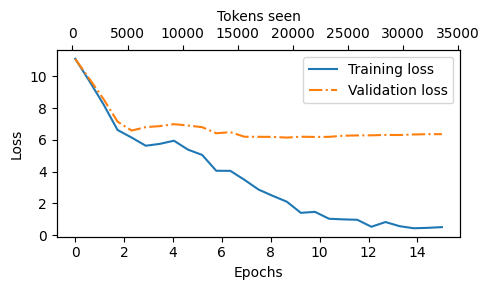

In [59]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()                   #1
    ax2.plot(tokens_seen, train_losses, alpha=0)     #2
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 5.3 Decoding Strategies to Control Randomness.

In [60]:
modelc = model.to("cpu")
modelc.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

In [62]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simplified(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [63]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [64]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [65]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [66]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [67]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
             for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [68]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

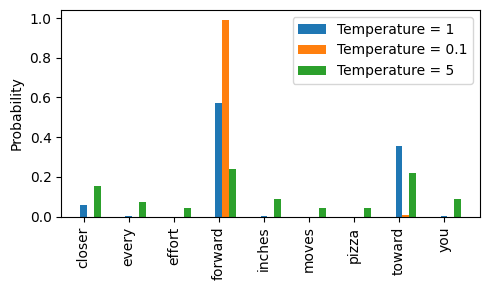

In [69]:
temperatures = [1, 0.1, 5]                                     #1
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                for T in temperatures]
x = torch.arange(len(vocab))
bar_width = 0.15
fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i],
                   bar_width, label=f'Temperature = {T}')
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()

Exercise 5.1
Use the print_sampled_tokens function to print the sampling frequencies of the softmax probabilities scaled with the temperatures shown in figure 5.14. How often is the word pizza sampled in each case? Can you think of a faster and more accurate way to determine how often the word pizza is sampled?

In [74]:
def print_sampled_tokens_with_temp(logits, temp = 0.0):
    probas = softmax_with_temperature(logits, temp)

    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item()
             for i in range(10000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

In [75]:
temp = [0.5, 1.0, 1.5]
for temp in temp:
  print_sampled_tokens_with_temp(next_token_logits, temp)

93 x closer
0 x every
0 x effort
7220 x forward
0 x inches
0 x moves
0 x pizza
2687 x toward
664 x closer
11 x every
0 x effort
5718 x forward
32 x inches
0 x moves
1 x pizza
3536 x toward
38 x you
1140 x closer
92 x every
10 x effort
4899 x forward
151 x inches
15 x moves
14 x pizza
3508 x toward
171 x you


### 5.3.2 TopK Sampling

In [76]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [77]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],    #1
    input=torch.tensor(float('-inf')),     #2
    other=next_token_logits     #3
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [ ]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

In [78]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):            #1
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        if top_k is not None:                #2
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )
        if temperature > 0.0:                  #3
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:    #4
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        if idx_next == eos_id:              #5
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx

In [81]:
torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.0
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?" I turned to surprise, one of his! She sent for me by


Exercise 5.2
Play around with different temperatures and top-k settings. Based on your observations, can you think of applications where lower temperature and top-k settings are desired? Likewise, can you think of applications where higher temperature and top-k settings are preferred? (It’s recommended to also revisit this exercise at the end of the chapter after loading the pretrained weights from OpenAI.)
Answer: Lower temperature - use cases requiring LLM to stick more to the original data distribution, higher temp - more "creative, diversified" text generation.

Exercise 5.3
What are the different combinations of settings for the generate function to force deterministic behavior, that is, disabling the random sampling such that it always produces the same outputs similar to the generate_simple function?
Answer: temp = 0.0, top_k = None, eos_id = None

## 5.4 Loading and saving model weights in PyTorch

In [84]:
torch.save(model.state_dict(), "model.pth")

In [86]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location = device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

In [ ]:
# 1. Correct way to save ONLY the weights (state_dict)
torch.save(model.state_dict(), "model_weights.pth")

# 2. Correct way to load the weights back into a new model instance
model_new = GPTModel(GPT_CONFIG_124M)
model_new.load_state_dict(torch.load("model_weights.pth", map_location=device))
model_new.to(device)
#Model.eval() switches off dropout layers during inference.
model_new.eval()

In [88]:
#Saving optimizer state useful for further training with optimizers sucha as AdamW maintaining learning rates for each parameter
torch.save(
    {"model_state_dict" : model.state_dict(),
     "optimizer_state_dict" : optimizer.state_dict()},
    "model_with_optimizer.pth",
)

In [107]:
device

device(type='cuda')

In [110]:
model_checkpoint = torch.load("model_with_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M).to(device)
model.load_state_dict(model_checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr = 5e-4,  weight_decay=0.1)
optimizer.load_state_dict(model_checkpoint["optimizer_state_dict"])
#model.to(device)
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_feature

Exercise 5.4
After saving the weights, load the model and optimizer in a new Python session or Jupyter notebook file and continue pretraining it for one more epoch using the train_model_simple function

In [111]:
#for param in model.parameters():
#    print(param.device)

In [112]:
device

device(type='cuda')

In [115]:
n_epochs = 15
model.to(device)
train_losses, val_losses, tokens_seen = train(
                        model, train_loader, val_loader, optimizer, device, num_epochs = n_epochs,
                        eval_freq = 5, eval_iter=1, start_context="Every effort moves you",
                        tokenizer = tokenizer,
                        )

A1
Batch 1 loss: 6.994961738586426
A1
Batch 1 loss: 7.551576614379883
Ep 1 (Step 000000): Train loss 6.995, Val loss 7.552
Every effort moves you, the, the, the, the.                                         
A1
Batch 1 loss: 7.101001739501953
A1
Batch 1 loss: 7.50772762298584
Ep 1 (Step 000005): Train loss 7.101, Val loss 7.508
Every effort moves you, the, the, the, the.                                         
A1
Batch 1 loss: 6.9106059074401855
A1
Batch 1 loss: 7.464195251464844
Ep 2 (Step 000010): Train loss 6.911, Val loss 7.464
Every effort moves you, the, the, the, the.                                         
A1
Batch 1 loss: 6.90876579284668
A1
Batch 1 loss: 7.421329498291016
Ep 2 (Step 000015): Train loss 6.909, Val loss 7.421
Every effort moves you, the, the, the, the.                                         
A1
Batch 1 loss: 6.626952171325684
A1
Batch 1 loss: 7.377684593200684
Ep 3 (Step 000020): Train loss 6.627, Val loss 7.378
Every effort moves you, the, the.             

## 5.5 Loading pretrained weights from OpenAI

In [116]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x25062ca44d0>)

In [117]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 7.83kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 1.22MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 16.7kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:09<00:00, 7.19MiB/s]  
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 1.03MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 837kiB/s] 
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 821kiB/s] 


In [118]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [119]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [120]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [131]:
NEW_CONFIG.update({"qkv_bias": True})
NEW_CONFIG.update({"context_length": 1024})

In [132]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=

In [133]:
def assign(left, right):
    print(left.shape, right.shape)
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [137]:
import numpy as np

def load_weights_into_gpt(gpt, params):           #1
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):     #2
        q_w, k_w, v_w = np.split(                            #3
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trns_blocks[b].att.W_query.weight = assign(
            gpt.trns_blocks[b].att.W_query.weight, q_w.T)
        gpt.trns_blocks[b].att.W_key.weight = assign(
            gpt.trns_blocks[b].att.W_key.weight, k_w.T)
        gpt.trns_blocks[b].att.W_value.weight = assign(
            gpt.trns_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trns_blocks[b].att.W_query.bias = assign(
            gpt.trns_blocks[b].att.W_query.bias, q_b)
        gpt.trns_blocks[b].att.W_key.bias = assign(
            gpt.trns_blocks[b].att.W_key.bias, k_b)
        gpt.trns_blocks[b].att.W_value.bias = assign(
            gpt.trns_blocks[b].att.W_value.bias, v_b)

        gpt.trns_blocks[b].att.out_proj.weight = assign(
            gpt.trns_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trns_blocks[b].att.out_proj.bias = assign(
            gpt.trns_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trns_blocks[b].ff.layers[0].weight = assign(
            gpt.trns_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trns_blocks[b].ff.layers[0].bias = assign(
            gpt.trns_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trns_blocks[b].ff.layers[2].weight = assign(
            gpt.trns_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trns_blocks[b].ff.layers[2].bias = assign(
            gpt.trns_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trns_blocks[b].norm1.scale = assign(
            gpt.trns_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trns_blocks[b].norm1.shift = assign(
            gpt.trns_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trns_blocks[b].norm2.scale = assign(
            gpt.trns_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trns_blocks[b].norm2.shift = assign(
            gpt.trns_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [138]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': True}

In [139]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

torch.Size([1024, 768]) (1024, 768)
torch.Size([50257, 768]) (50257, 768)
torch.Size([768, 768]) (768, 768)
torch.Size([768, 768]) (768, 768)
torch.Size([768, 768]) (768, 768)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768, 768]) (768, 768)
torch.Size([768]) (768,)
torch.Size([3072, 768]) (3072, 768)
torch.Size([3072]) (3072,)
torch.Size([768, 3072]) (768, 3072)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768, 768]) (768, 768)
torch.Size([768, 768]) (768, 768)
torch.Size([768, 768]) (768, 768)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768, 768]) (768, 768)
torch.Size([768]) (768,)
torch.Size([3072, 768]) (3072, 768)
torch.Size([3072]) (3072,)
torch.Size([768, 3072]) (768, 3072)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.Size([768]) (768,)
torch.

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trns_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=

Exercise 5.5
Calculate the training and validation set losses of the GPTModel with the pretrained weights from OpenAI on the “The Verdict” dataset.

In [140]:
with torch.no_grad():
    loader_loss = calculate_loss_loader(train_loader, gpt, device, 100)
loader_loss

A1
Batch 1 loss: 3.939962148666382
Batch 2 loss: 3.3484673500061035
Batch 3 loss: 3.5073084831237793
Batch 4 loss: 3.898252487182617
Batch 5 loss: 3.5500717163085938
Batch 6 loss: 3.886458158493042
Batch 7 loss: 4.052453994750977
Batch 8 loss: 3.991373300552368
Batch 9 loss: 3.618520736694336


3.7547631528642444

In [141]:
with torch.no_grad():
    loader_loss = calculate_loss_loader(val_loader, model, device, 100)
loader_loss

A1
Batch 1 loss: 6.805375576019287


6.805375576019287

In [1]:
import torch

In [2]:
torch.cuda.is_available()

True